In [99]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
from collections import defaultdict
from sklearn import metrics

cwd = Path.cwd().resolve()
for p in cwd.parents:
    if (p / '.git').exists():
        %cd {str(p)}
        break

In [15]:
df = pd.read_csv('data/processed/order_delivery_dataset.csv')
df.head()

,order_id,order_approved_at,order_delivered_carrier_date,customer_lat,customer_lng,customer_state,seller_lat,seller_lng,seller_state,distance_km,item_count,volume_m3,weight_kg,total_price,total_freight_value,handling_days,transit_days,total_delivery_days
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 09:45:35,2017-09-19 18:34:16,-21.762775,-41.309633,RJ,-22.496953,-44.127492,RJ,301.504681,1,0.003528,0.65,58.90,13.29,6.367141,1.214954,7.582095
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 11:05:13,2017-05-04 14:35:00,-20.220527,-50.903424,SP,-23.565096,-46.518565,SP,585.563937,1,0.060000,30.00,239.90,19.93,8.145683,8.062083,16.207766
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:48:30,2018-01-16 12:36:48,-19.870305,-44.593326,MG,-22.262584,-46.171124,MG,312.343511,1,0.014157,3.05,199.00,17.87,1.908542,6.029491,7.938032
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:10:18,2018-08-10 13:28:00,-23.089925,-46.611654,SP,-20.553624,-47.387359,SP,293.168420,1,0.002400,0.20,12.99,12.79,2.137292,4.003229,6.140521
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 14:10:13,2017-02-16 09:46:09,-23.243402,-46.827614,SP,-22.929384,-53.135873,PR,646.163463,1,0.042000,3.75,199.90,18.14,11.816620,13.289144,25.105764


In [16]:
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])

# Data Split

In [17]:
df['order_approved_at'].groupby(df.order_approved_at.dt.to_period('M')).count()

order_approved_at
2017-01     711
2017-02    1626
2017-03    2548
2017-04    2236
2017-05    3502
2017-06    3115
2017-07    3763
2017-08    4137
2017-09    4113
2017-10    4378
2017-11    7055
2017-12    5610
2018-01    6889
2018-02    6450
2018-03    6994
2018-04    6143
2018-05    6761
2018-06    5895
2018-07    5397
2018-08    6276
Freq: M, Name: order_approved_at, dtype: int64

2017 will be used for training
2018 will be used for testing

In [18]:
df_train = df[df['order_approved_at'].between('2017-01-01', '2017-12-31')]
df_test = df[df['order_approved_at'].between('2018-01-01', '2018-12-31')]

# Feature Engineering and Selection

<Axes: xlabel='order_approved_at', ylabel='handling_days'>

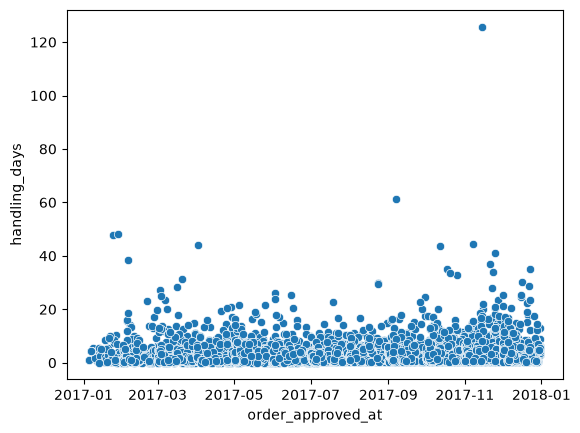

In [19]:
scatter_data = df_train.groupby(df_train['order_approved_at'].dt.to_period('M'), group_keys = False).apply(lambda x : x.sample(frac = 0.2))
sns.scatterplot(data = scatter_data, x = 'order_approved_at', y = 'handling_days')

doesnt seems to be exhibiting trend

(-0.5, 20.0)

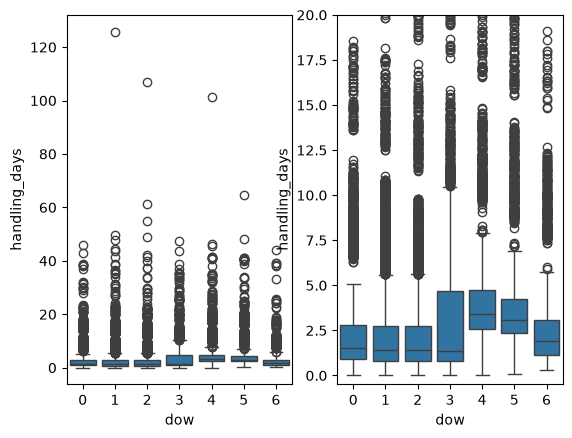

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2)
df_train['dow'] = df_train['order_approved_at'].dt.day_of_week

sns.boxplot(df_train, x = 'dow', y = 'handling_days', ax = ax1)
sns.boxplot(df_train, x = 'dow', y = 'handling_days', ax = ax2)
ax2.set_ylim(-0.5, 20)

handling days appear to have a clear seasonality, in particular, order approved during friday, saturday, and sunday take longer time to be handled

In [21]:
candidate_features = ['dow', 'seller_state', 'seller_lat', 'seller_lng', 'item_count', 'volume_m3', 'weight_kg']

Features such as seller location and distance are not selected because they are deemed irrelevant

In [53]:
class ZScore:
    def __init__(self, alpha = 0.05):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.array(X)
        y = pd.Series(y)
        
        self.mean = y.groupby(list(X.T)).mean()
        self.std = y.groupby(list(X.T)).std()
        
    def predict(self, X, y):
        X = np.array(X)
        y = np.array(y)
        if X.shape[1] > 1:
            center = self.mean[list(map(tuple, X))]
        else: 
            center = self.mean[X[:, 0]]
        upper_bound = center + ss.norm.ppf(1 - self.alpha) * self.std

        return {
            'is_outlier' : (upper_bound < y).astype(int),
            'center' : center
        }
        
        
zscore = ZScore(alpha = 0.01)
zscore.fit(df_train[['dow']], df_train['handling_days'])
zscore.mean
zscore.predict(df_train[['dow']], df_train['handling_days'])['is_outlier'].mean()

np.float64(0.027636721035265484)

In [119]:
def evaluate(model, X_list, y_list, period_train, period_test):
    """
    period_train : in months
    period_test : in months
    """
    for i, (X, y) in enumerate(zip(X_list, y_list)):
        X_list[i] = np.array(X)
        y_list[i] = np.array(y)

    N = len(X_list) - period_train - period_test + 1
    results = defaultdict(list)
    for i in range(N):
        X_train = np.concatenate(X_list[i : i + period_train], axis = 0)
        y_train = np.concatenate(y_list[i : i + period_train], axis = 0)
        X_test = np.concatenate(X_list[i + period_train : i + period_train + period_test], axis = 0)
        y_test = np.concatenate(y_list[i + period_train : i + period_train + period_test], axis = 0)

        model.fit(X_train, y_train)
        preds = model.predict(X_test, y_test)

        results['outlier_frac'].append(preds['is_outlier'].mean().item())
        results['rmse_center'].append(metrics.root_mean_squared_error(y_test, preds['center']))
        results['N'].append(len(y_test))
        
    for k in results.keys():
        results[k] = np.array(results[k])
    return results
        

results = evaluate(
    model = zscore, 
    X_list = [g[1] for g in df_train[['dow']].groupby(by = df_train.order_approved_at.dt.to_period('M'), sort = True)], 
    y_list = [g[1] for g in df_train['handling_days'].groupby(by = df_train.order_approved_at.dt.to_period('M'), sort = True)],
    period_train = 3, 
    period_test = 1,
)

def aggregate_metrics(result):
    return  {
        'outlier_frac' : np.average(result['outlier_frac'], weights = result['N']).item(),
        'rmse_outlier_frac' : np.sqrt(((result['outlier_frac'] - 0.05)**2).mean()).item(),
        'weighted_rmse_outlier_frac' : np.sqrt(np.average((result['outlier_frac'] - 0.05)**2, weights = result['N'])).item(),
        'rmse_center' : np.sqrt(np.average(results['rmse_center'] ** 2, weights = result['N'])).item()
    }
    
results['outlier_frac'].mean()
aggregate_metrics(results)

{'outlier_frac': 0.03358169520186007,
 'rmse_outlier_frac': 0.02088716232958555,
 'weighted_rmse_outlier_frac': 0.019850000738200483,
 'rmse_center': 3.5196441400130642}